<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/avalia%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação de Algoritmos de Classificação

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
# Giordano
y_real    = [0, 0, 1, 1, 0, 0, 0, 1, 1, 1]
y_predito = [0, 1, 0, 0, 0, 0, 0, 1, 1, 0]

In [13]:
# Matriz de Confusão
matriz_conf = confusion_matrix(y_real, y_predito)

In [14]:
print(matriz_conf)

[[4 1]
 [3 2]]


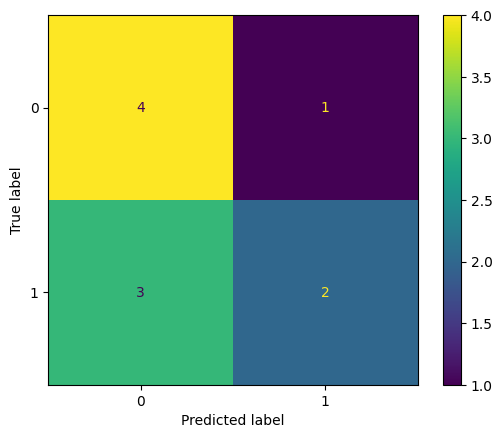

In [17]:
ConfusionMatrixDisplay(matriz_conf).plot()

In [7]:
print(matriz_conf.ravel())

[4 1 3 2]


# Acurácia

$$ acc = \frac{VP + VN} {VP + VN + FP + FN} $$

# Precisão

$$ prec = \frac{VP} {VP + FP} $$

# Recall

$$ rec = \frac{VP} {VP + FN} $$

# F1 Score

$$ f1 = 2 * \frac {prec * rec} {prec + rec} $$

In [9]:
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             recall_score,
                             precision_score
)

In [16]:
print(f'Acurácia...................: {accuracy_score(y_real, y_predito)}')
print(f'Precisão...................: {precision_score(y_real, y_predito)}')
print(f'Recall.....................: {recall_score(y_real, y_predito)}')
print(f'F1.........................: {f1_score(y_real, y_predito)}')

Acurácia...................: 0.6
Precisão...................: 0.6666666666666666
Recall.....................: 0.4
F1.........................: 0.5


In [18]:
from sklearn.metrics import classification_report

In [19]:
print(classification_report(y_real, y_predito))

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.67      0.40      0.50         5

    accuracy                           0.60        10
   macro avg       0.62      0.60      0.58        10
weighted avg       0.62      0.60      0.58        10



In [20]:
from sklearn.datasets import load_wine

In [21]:
dados_vinho = load_wine()

In [24]:
print(dados_vinho.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [25]:
X = dados_vinho.data
y = dados_vinho.target

In [26]:
X.shape, y.shape

((178, 13), (178,))

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state=42)

In [29]:
# Mais bagaceira
from sklearn.linear_model import LogisticRegression

In [30]:
lr = LogisticRegression()

In [ ]:
lr.fit(X_treino, y_treino)

In [32]:
lr_predict = lr.predict(X_teste)

In [33]:
print(classification_report(y_teste, lr_predict))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.95      1.00      0.97        18
           2       1.00      1.00      1.00        12

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



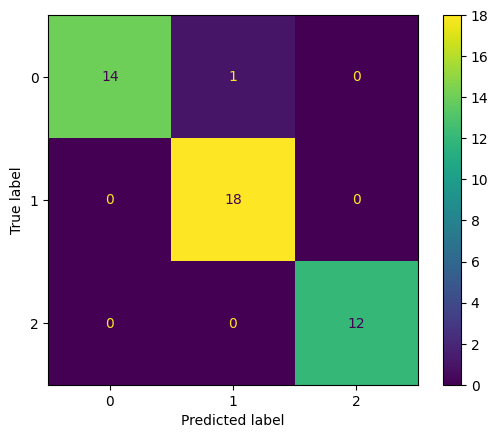

In [34]:
ConfusionMatrixDisplay(confusion_matrix(y_teste, lr_predict)).plot()

In [35]:
from sklearn.neighbors import KNeighborsClassifier

In [36]:
knn = KNeighborsClassifier(n_neighbors=5)

In [37]:
knn.fit(X_treino, y_treino)

KNeighborsClassifier()

In [39]:
knn_predict = knn.predict(X_teste)

In [40]:
print(classification_report(y_teste, knn_predict))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.72      0.72      0.72        18
           2       0.50      0.50      0.50        12

    accuracy                           0.71        45
   macro avg       0.70      0.70      0.70        45
weighted avg       0.71      0.71      0.71        45



In [45]:
X_treino[3]

array([1.258e+01, 1.290e+00, 2.100e+00, 2.000e+01, 1.030e+02, 1.480e+00,
       5.800e-01, 5.300e-01, 1.400e+00, 7.600e+00, 5.800e-01, 1.550e+00,
       6.400e+02])

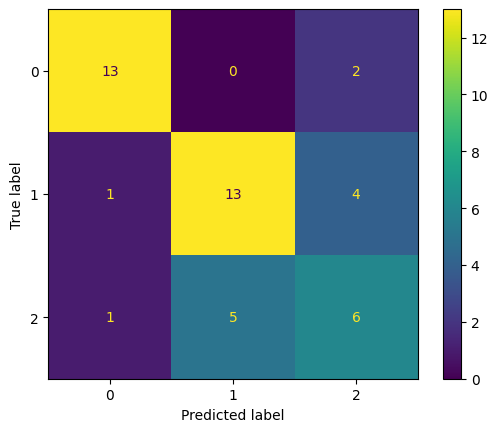

In [46]:
ConfusionMatrixDisplay(confusion_matrix(y_teste, knn_predict)).plot()

In [49]:
from sklearn.svm import SVC

In [54]:
svm = SVC(kernel='linear')

In [55]:
svm.fit(X_treino, y_treino)

SVC(kernel='linear')

In [56]:
svm_predict = svm.predict(X_teste)

In [57]:
print(classification_report(y_teste, svm_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

